This notebook contains example code for computing X-ray photon-count profiles in BaryonForge. It requires an emissivity function that translates temperature and metallicity into photon counts using APEC plasma-emission calculations. Credit to [Kritti Sharma](https://sites.google.com/view/krittisharma/) for the example code that constructs the emissivity function from the APEC fit files.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys, os; sys.path.insert(0, '../')
import BaryonForge as bfg
import pyccl as ccl
import fitsio
from tqdm import tqdm

#Load cosmology object from CCL. Linear P(k) is needed since we use it for 2-halo term.
#We don't use P(k) anywhere else in this model, so it's ok to use linear P(k) throughout
cosmo = ccl.Cosmology(Omega_c = 0.26, Omega_b = 0.04, h = 0.7, sigma8 = 0.8, n_s = 0.96, matter_power_spectrum='linear')
h     = cosmo.cosmo.params.h

#Config params. Can change as you need. I store these as a dict and then unpack.
bpar_S19 = dict(theta_ej = 4, theta_co = 0.1, M_c = 1e14/h, mu_beta = 0.4,
                eta = 0.3, eta_delta = 0.3, tau = -1.5, tau_delta = 0, #Must use tau here since we go down to low mass
                A = 0.09/2, M1 = 2.5e11/h, epsilon_h = 0.015, 
                a = 0.3, n = 2, epsilon = 4, p = 0.3, q = 0.707, gamma = 2, delta = 7)

bpar_A20 = dict(alpha_g = 2, epsilon_h = 0.015, M1_0 = 2.2e11/h, 
                alpha_fsat = 1, M1_fsat = 1, delta_fsat = 1, gamma_fsat = 1, eps_fsat = 1,
                M_c = 1.2e14/h, eta = 0.6, mu = 0.31, beta = 0.6, epsilon_hydro = np.sqrt(5),
                M_inn = 3.3e13/h, M_r = 1e16, beta_r = 2, theta_inn = 0.1, theta_out = 3,
                theta_rg = 0.3, sigma_rg = 0.1, a = 0.3, n = 2, p = 0.3, q = 0.707,
                A_nt = 0.495, alpha_nt = 0.1,
                mean_molecular_weight = 0.59)


#Thermodynamic params
bpar_tms = dict(alpha_nt = 0.3, gamma_nt = 0.3, nu_nt = 0.3, 
                gamma_Z_core = 3.0, theta_Z_core = 0.1, Z_core = 0.8, Z_out = 0.3, 
                mean_molecular_weight = 1.15, mu_Z_core = 0.05)

bpar     = (bpar_S19 | bpar_tms)

In [2]:
#Some plotting configs
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=22)
plt.rcParams["axes.linewidth"]  = 2.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]

# Compute the emissivity Table for your experiment

This has nothing to do with BaryonForge. You can compute this however you want. If you have instrumental effects, like responses and redistribution matrices, they will be included in this step. The final function should return the observed photon counts in a given band given a temperature, metallicity, redshift.

The code below downloads the relevant files from AtomDB to perform this calculation.

In [3]:
import os, shutil, subprocess, tempfile

url = "http://www.atomdb.org/download_process?fname=apec_v3_1_3"

with tempfile.TemporaryDirectory() as tmpdir:
    # Step 1: wget download
    subprocess.run(
        [
            "wget",
            "-q",
            "--content-disposition",
            url,
        ],
        cwd=tmpdir,
        check=True,
    )

    # Find the downloaded tar file (name comes from server)
    tar_files = [f for f in os.listdir(tmpdir) if f.endswith(".tar.bz2")]
    tar_path  = os.path.join(tmpdir, tar_files[0])
    
    # Step 2: extract
    subprocess.run(
        ["tar", "-xjf", tar_path],
        cwd=tmpdir,
        check=True,
    )

    # Step 3: locate apec_coco.fits (may be inside subdirectory)
    for root, _, files in os.walk(tmpdir):
        if "apec_coco.fits" in files:
            coco_path = os.path.join(root, "apec_coco.fits")
            break

    for root, _, files in os.walk(tmpdir):
        if "apec_line.fits" in files:
            line_path = os.path.join(root, "apec_line.fits")
            break

    # Step 4: copy to output directory
    shutil.copyfile(coco_path, os.path.abspath("./apec_coco.fits"))
    shutil.copyfile(line_path, os.path.abspath("./apec_line.fits"))

In [4]:
line = fitsio.FITS('./apec_line.fits')
cont = fitsio.FITS('./apec_coco.fits')

In [5]:
kT_grid = np.array(line[1].read()['kT'])

n_T         = len(kT_grid)
T_kelvin    = kT_grid / bfg.utils.K_to_kev #EmissivityTable wants physical Kelvin, not keV
erg_per_keV = 1.602e-9

metal_grid  = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5])
z_grid      = np.array([0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0])
E_min_obs   = 0.5    # keV, observer frame
E_max_obs   = 2.0    # keV, observer frame

n_Z    = len(metal_grid)
n_z    = len(z_grid)
n_elem = 30
J_grid = np.zeros((n_T, n_Z, n_z))

print(f"Computing {n_Z} metallicities x {n_z} redshifts x {n_T} temperatures")
print(f"Observer band: [{E_min_obs}, {E_max_obs}] keV")

Computing 8 metallicities x 9 redshifts x 201 temperatures
Observer band: [0.5, 2.0] keV


In [6]:
with tqdm(total=n_z * n_T * n_elem, desc="Computing spectra", unit = " elem") as pbar:

    for iT in range(n_T):
        hdu_index = iT + 2 #First 2 hdus are utilities, rest are for each temp
        ldat = line[hdu_index].read()
        cdat = cont[hdu_index].read()

        for iz, z in enumerate(z_grid):

            # Rest-frame energy band shifts with redshift
            E_lo = E_min_obs * (1 + z)
            E_hi = E_max_obs * (1 + z)

            # lin-spaced energy grid over rest-frame band
            ebins = np.logspace(np.log10(E_lo), np.log10(E_hi), 2000)
            emids = (ebins[:-1] + ebins[1:])/2
            dE    = np.diff(ebins)
            
            # Compute per-element spectra once, split light vs metals
            # Epsilon already at solar abundance
            spec_light  = np.zeros(len(emids)) # H + He (scale=1)
            spec_metals = np.zeros(len(emids)) # metals at 1x solar (will scale by metallicity)

            for Z in range(1, 1 + n_elem):
                spec_Z = np.zeros(len(emids))

                # Lines
                mask = (ldat['Element'] == Z) & (ldat['Lambda'] > 0)
                if np.any(mask):
                    e_keV = 12.398 / ldat['Lambda'][mask]
                    eps   = ldat['Epsilon'][mask]
                    inr   = (e_keV >= E_lo) & (e_keV <= E_hi)
                    if np.any(inr):
                        ibins = np.searchsorted(ebins, e_keV[inr]) - 1
                        valid = (ibins >= 0) & (ibins < len(spec_Z))
                        np.add.at(spec_Z, ibins[valid], eps[inr][valid])

                # Continuum
                cmask = (cdat['Z'] == Z)
                if np.any(cmask):
                    for row in cdat[cmask]:
                        nc = row['N_Cont']
                        ec = row['E_Cont'][:nc]
                        c  = row['Continuum'][:nc]
                        np_ = row['N_Pseudo']
                        ep  = row['E_Pseudo'][:np_]
                        p   = row['Pseudo'][:np_]
                        if len(ec) > 1: spec_Z += np.interp(emids, ec, c, left=0, right=0) * dE
                        if len(ep) > 1: spec_Z += np.interp(emids, ep, p, left=0, right=0) * dE

                if Z <= 2: spec_light  += spec_Z
                else:      spec_metals += spec_Z
                    
                pbar.update(1)

            # Apply each metallicity, just a scalar multiply
            for iZ, met in enumerate(metal_grid):
                J_grid[iT, iZ, iz] = np.sum((spec_light + met * spec_metals))

Computing spectra: 100%|██████████| 54270/54270 [00:17<00:00, 3099.44 elem/s]


# Compute profiles

In [7]:
#Put the table into the dedicated BaryonForge object to regularize I/O
#The emissivities need to be in COMOVING VOLUME/DENSITY units, because the 
#number densities in CCL/baryonForge are all in comoving distances
J_grid            = J_grid * (1 + z_grid[None, None, :])**3 #convert cm^3 ---> comoving cm^3
T_in, Z_in, a_in  = np.meshgrid(T_kelvin, metal_grid, 1/(1 + z_grid), indexing = 'ij')
Emissivity_Table  = bfg.utils.Xray.EmissivityTable(T_in, Z_in, a_in, J_grid, regular_grid = True)


#Define temperature and metallicity
Temperature = bfg.Thermodynamic.Temperature(**bpar) #By default this accounts for nonthermal pressure 
Metallicity = bfg.Thermodynamic.Metallicity(**bpar)


#Now, build an emissivity table, which requires inputs on radial profiles of
#the temperature and the metallicity
EmissivityProfile = bfg.Profiles.Emissivity(Emissivity_Table, temperature = Temperature, metallicity = Metallicity, **bpar)

#Construct the number densities, these are in comoving densities
Gas               = bfg.Profiles.Schneider19.Gas(**bpar)
n_e_profile       = bfg.Profiles.GasNumberDensity(**bpar)

#For the hydrogen one, use the same params, but drop mean_molecular weight and 
#pass it in manually. Our original value in bpar is for electrons.
cut_bpar          = {k:v for k,v in bpar.items() if k != 'mean_molecular_weight'}
n_H_profile       = bfg.Profiles.GasNumberDensity(**cut_bpar, mean_molecular_weight = 1/0.76) #Using X = 0.76 hydrogen frac.

#The countrate profile can be constructed using all of these
CountRateProfile  = bfg.Profiles.XrayCounts(EmissivityProfile, n_e_profile, n_H_profile, **bpar)

## Metallicity profiles

Sort of designed to match Fig 3 in https://arxiv.org/pdf/1811.01967.

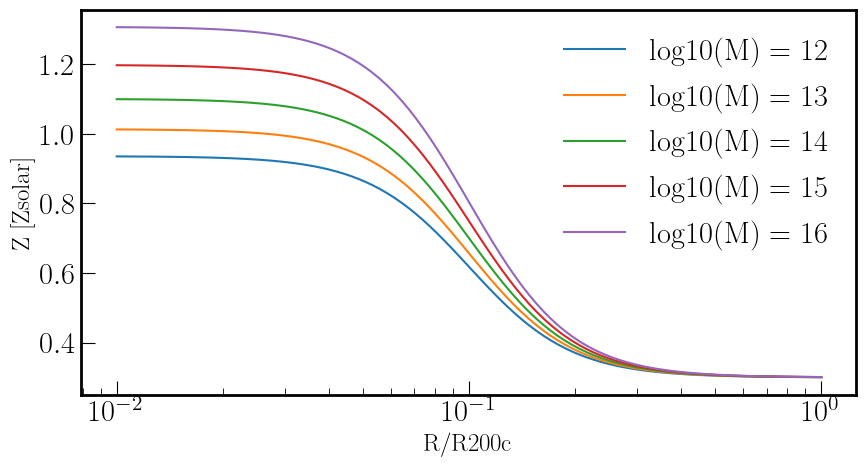

In [8]:
plt.figure(figsize = (10,5))
a = 1
for M in [1e12, 1e13, 1e14, 1e15, 1e16]:

    R     = np.geomspace(0.01, 1, 100)
    R200c = Metallicity.mass_def.get_radius(cosmo, M, a)/a #in comoving Mpc

    plt.plot(R, Metallicity.real(cosmo, R * R200c, M, a), label = f'log10(M) = {int(np.log10(M))}')


plt.xscale('log')
plt.ylabel('Z [Zsolar]', size = 18)
plt.xlabel('R/R200c', size = 18)
plt.legend()

## Emissivity profiles

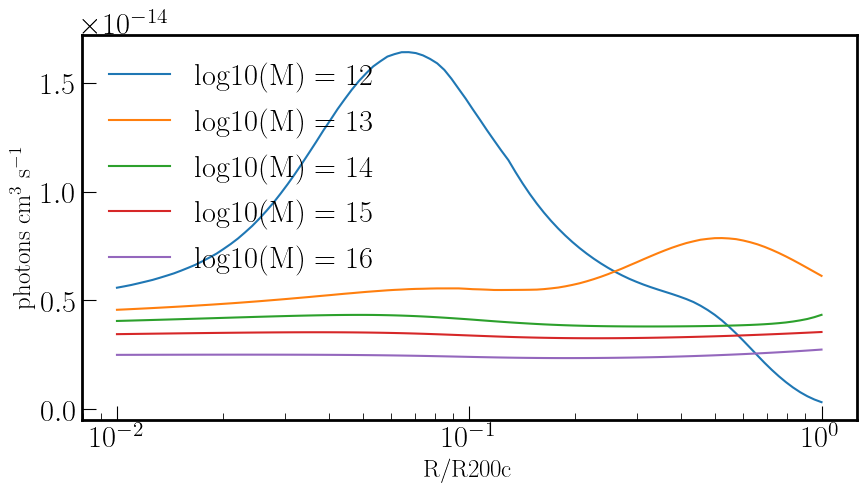

In [9]:
plt.figure(figsize = (10,5))
a = 1
for M in [1e12, 1e13, 1e14, 1e15, 1e16]:

    R     = np.geomspace(0.01, 1, 100)
    R200c = EmissivityProfile.mass_def.get_radius(cosmo, M, a)/a #in comoving Mpc

    plt.plot(R, EmissivityProfile.real(cosmo, R * R200c, M, a), label = f'log10(M) = {int(np.log10(M))}')


plt.xscale('log')
plt.ylabel(r'photons cm$^3$ s$^{-1}$', size = 18)
plt.xlabel('R/R200c', size = 18)
plt.legend()

## 3D X-ray count profiles

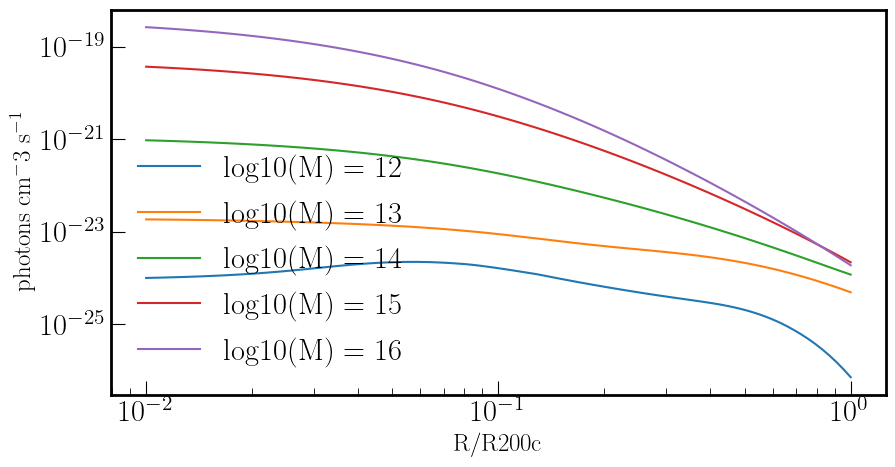

In [10]:
plt.figure(figsize = (10,5))
a = 1
for M in [1e12, 1e13, 1e14, 1e15, 1e16]:

    R     = np.geomspace(0.01, 1, 100)
    R200c = EmissivityProfile.mass_def.get_radius(cosmo, M, a)/a #in comoving Mpc

    plt.plot(R, CountRateProfile.real(cosmo, R * R200c, M, a), label = f'log10(M) = {int(np.log10(M))}')

plt.loglog()
plt.ylabel(r'photons cm$^-3$ s$^{-1}$', size = 18)
plt.xlabel('R/R200c', size = 18)
plt.legend()

## Cluster scaling relations

In [11]:
Mpc_to_cm = (bfg.utils.constants.Mpc_to_m * bfg.utils.constants.m_to_cm)

In [12]:
M = np.geomspace(1e12, 1e16, 30)
r = np.geomspace(1e-3, 100, 300)
c = CountRateProfile.real(cosmo, r, M, a)

total_counts = np.trapz(4 * np.pi * (r*Mpc_to_cm)**2 * c, r*Mpc_to_cm, axis = 1)
total_energy = total_counts * 1.6e-9

Text(0, 0.5, 'Lx [ergs/s]')

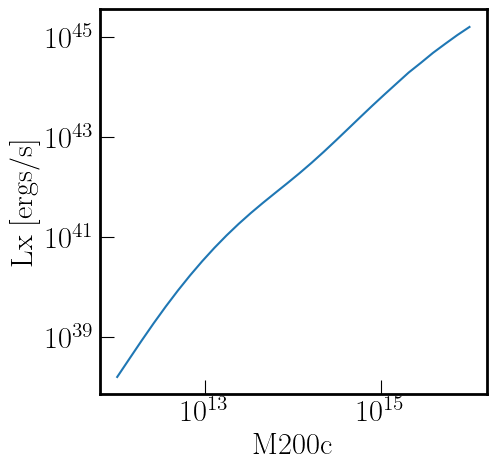

In [13]:
plt.figure(figsize = (5,5))
plt.loglog()
plt.plot(M, total_energy)
plt.xlabel('M200c')
plt.ylabel('Lx [ergs/s]')